# Etude de cas : analyse des fichiers de logs des cyclistes

Objectif: A partir des fichiers contenu dans le dossier ./data/Cyclistes, calculer la durée de chacun des trajets effectués par chaque cycliste.

In [79]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.functions import udf, col
from pyspark.sql.window import Window
from datetime import datetime

## 1)  Charger la donnée
Créez une seesion Spark et chargez les données Cyclistes.

In [80]:
spark = SparkSession.builder.appName("AnalyseCyclistes").getOrCreate()

In [81]:
df = spark.read.csv( "./data/Cyclistes/*.csv", header=True ,inferSchema=True )

In [82]:
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- sur_velo: boolean (nullable = true)
 |-- velo: string (nullable = true)
 |-- vitesse: double (nullable = true)
 |-- position: string (nullable = true)
 |-- destination_finale: string (nullable = true)



In [83]:
# Aperçu des données
df.show(5)

+---+-------------------+--------+-----+--------------------+-------------------+------------------+
| id|          timestamp|sur_velo| velo|             vitesse|           position|destination_finale|
+---+-------------------+--------+-----+--------------------+-------------------+------------------+
| 12|2018-01-01 00:01:00|   false|False|0.030000000000000006|(lon:2.07 lat:1.24)|             False|
| 12|2018-01-01 00:02:00|   false|False|0.030000000000000006|(lon:2.07 lat:1.24)|             False|
| 12|2018-01-01 00:03:00|   false|False|0.030000000000000006|(lon:2.07 lat:1.24)|             False|
| 12|2018-01-01 00:04:00|   false|False|0.030000000000000006|(lon:2.07 lat:1.24)|             False|
| 12|2018-01-01 00:05:00|   false|False|0.030000000000000006|(lon:2.07 lat:1.24)|             False|
+---+-------------------+--------+-----+--------------------+-------------------+------------------+
only showing top 5 rows



## 2) Vérifier le nombre de cyclistes

Comptez le nombre d'id uniques.

In [84]:
df.select("id").distinct().count()

50

In [85]:
# variante équivalente avec countDistinct
df.select(F.countDistinct("id").alias("nb_cyclistes")).show()

+------------+
|nb_cyclistes|
+------------+
|          50|
+------------+



## 3) Transformer la colonne timestamp

Lorsqu'on vérifie le type de donnée de la colonne timestamp, on voit qu'on a une chaîne de caractères. Pour calculer une durée on voudrait transformer en date exploitable en tant que telle.
A l'aide d'une fonction udf, créez une nouvelle colonne date qui contiendra le résultat de la transformation des chaînes de caractères de la colonne timestamp en véritables timestamps.

In [86]:
# Avec inferSchema, timestamp peut déjà être un type Spark ; l'UDF accepte str ou datetime.
def parse_timestamp(x):
    if x is None:
        return None
    if isinstance(x, datetime):
        return x
    s = str(x)
    if len(s) >= 19:
        s = s[:19]
    return datetime.strptime(s, "%Y-%m-%d %H:%M:%S")


parse_timestamp_udf = udf(parse_timestamp, TimestampType())
df = df.withColumn("date", parse_timestamp_udf(F.col("timestamp")))

In [76]:
# (logique regroupée dans la cellule précédente)

In [35]:
# df["date"] est créée ci-dessus ; vous pouvez vérifier avec df.select("timestamp", "date").show(3)

## 4) Durée des trajets par id.

1) Trouvez les dates min/max par état de sur_velo, puis par id ET par état de sur_velo.

In [87]:
df.groupBy("sur_velo").agg(F.min("timestamp"),
                           F.max("timestamp")).show()

+--------+-------------------+-------------------+
|sur_velo|     min(timestamp)|     max(timestamp)|
+--------+-------------------+-------------------+
|    true|2018-01-01 01:47:00|2018-01-31 21:32:00|
|   false|2018-01-01 00:01:00|2018-02-01 00:00:00|
+--------+-------------------+-------------------+



In [101]:
df.groupBy("id", "sur_velo").agg(
    F.min("timestamp").alias("date_min"),
    F.max("timestamp").alias("date_max"),
).orderBy("id", "sur_velo").show()

+---+--------+-------------------+-------------------+
| id|sur_velo|           date_min|           date_max|
+---+--------+-------------------+-------------------+
|  2|   false|2018-01-01 00:01:00|2018-02-01 00:00:00|
|  2|    true|2018-01-01 12:33:00|2018-01-31 20:02:00|
|  3|   false|2018-01-01 00:01:00|2018-02-01 00:00:00|
|  3|    true|2018-01-06 06:24:00|2018-01-28 19:33:00|
|  4|   false|2018-01-01 00:01:00|2018-02-01 00:00:00|
|  4|    true|2018-01-06 09:48:00|2018-01-28 15:19:00|
|  5|   false|2018-01-01 00:01:00|2018-02-01 00:00:00|
|  5|    true|2018-01-06 12:35:00|2018-01-28 16:04:00|
|  6|   false|2018-01-01 00:01:00|2018-02-01 00:00:00|
|  6|    true|2018-01-01 07:07:00|2018-01-30 20:01:00|
|  7|   false|2018-01-01 00:01:00|2018-02-01 00:00:00|
|  7|    true|2018-01-01 06:33:00|2018-01-31 18:43:00|
|  8|   false|2018-01-01 00:01:00|2018-02-01 00:00:00|
|  8|    true|2018-01-06 05:14:00|2018-01-28 19:44:00|
|  9|   false|2018-01-01 00:01:00|2018-02-01 00:00:00|
|  9|    t

2) Le résultat n'est pas trés pertinent, il faudrait plutôt le début et la fin de chaque trajet par id. Pour cela, il faudrait détecter les changements d'état "sur_vélo".

Créez une fonction python (voir fonction udf) qui permet de detecter ces changements d'état.
Utilisez la classe Window() et la fonction F.lag() avec votre fonction udf pour créer une nouvelle colonne que vous appellerez changement, contenant un 0 si l'état précedent de sur_velo est le même et un 1 si l'état vient de changer pour chaque id.

In [89]:
window = Window.partitionBy("id").orderBy("timestamp")

In [109]:
def detecte_changement(etat_courant, etat_precedent):
    """1 si changement d'état ou première ligne du cycliste, 0 sinon."""
    if etat_precedent is None:
        return 1
    return 0 if etat_courant == etat_precedent else 1


detecte_changement_udf = udf(detecte_changement, IntegerType())

df = df.withColumn("sur_velo_prec", F.lag("sur_velo").over(window))
df = df.withColumn(
    "changement",
    detecte_changement_udf(F.col("sur_velo"), F.col("sur_velo_prec")),
)
df.select("id", "timestamp", "sur_velo", "sur_velo_prec", "changement").show(50)

+---+-------------------+--------+-------------+----------+
| id|          timestamp|sur_velo|sur_velo_prec|changement|
+---+-------------------+--------+-------------+----------+
| 26|2018-01-01 00:01:00|   false|         NULL|         1|
| 26|2018-01-01 00:02:00|   false|        false|         0|
| 26|2018-01-01 00:03:00|   false|        false|         0|
| 26|2018-01-01 00:04:00|   false|        false|         0|
| 26|2018-01-01 00:05:00|   false|        false|         0|
| 26|2018-01-01 00:06:00|   false|        false|         0|
| 26|2018-01-01 00:07:00|   false|        false|         0|
| 26|2018-01-01 00:08:00|   false|        false|         0|
| 26|2018-01-01 00:09:00|   false|        false|         0|
| 26|2018-01-01 00:10:00|   false|        false|         0|
| 26|2018-01-01 00:11:00|   false|        false|         0|
| 26|2018-01-01 00:12:00|   false|        false|         0|
| 26|2018-01-01 00:13:00|   false|        false|         0|
| 26|2018-01-01 00:14:00|   false|      

In [91]:
# Fenêtre cumulative : la somme par défaut sur une Window sans rowsBetween est incorrecte pour un cumul.
window_cumul = (
    Window.partitionBy("id")
    .orderBy("timestamp")
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
)


3) Grâce à cette nouvelle colonne changement, trouvez un moyen qui permettra de numeroter les trajets pour chaque id et stockez les résulats dans une nouvelle colonne appelée numero_de_trajet.

In [92]:
df = df.withColumn(
    "numero_de_trajet",
    F.sum("changement").over(window_cumul),
)


In [78]:
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- sur_velo: boolean (nullable = true)
 |-- velo: string (nullable = true)
 |-- vitesse: double (nullable = true)
 |-- position: string (nullable = true)
 |-- destination_finale: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- changement: boolean (nullable = true)
 |-- changement_int: integer (nullable = true)
 |-- numero_de_trajet: long (nullable = true)



4) Il suffit maintenant de repêter la première étape, c'est a dire récupérer la début et la fin de chaque trajet pour chaque id, puis calculer la durée des trajets. 

(Pensez à récuperer les "vrai trajet au préalable (avec un état sur_vélo = 1).

In [117]:
# Vrais trajets (sur_velo = True), puis min/max par id et segment — comme à l'étape 1
trajets = (
    df.filter(F.col("sur_velo"))
    .groupBy("id", "numero_de_trajet")
    .agg(
        F.min("timestamp").alias("debut_trajet"),
        F.max("timestamp").alias("fin_trajet"),
    )
    .withColumn(
        "duree_trajet_minutes",
        (F.unix_timestamp("fin_trajet") - F.unix_timestamp("debut_trajet")) / 60,
    )
    .orderBy("id", "debut_trajet")
)

trajets.show(50)

+---+----------------+-------------------+-------------------+--------------------+
| id|numero_de_trajet|       debut_trajet|         fin_trajet|duree_trajet_minutes|
+---+----------------+-------------------+-------------------+--------------------+
|  2|               2|2018-01-01 12:33:00|2018-01-01 12:36:00|                 3.0|
|  2|               4|2018-01-01 19:59:00|2018-01-01 20:00:00|                 1.0|
|  2|               6|2018-01-02 12:33:00|2018-01-02 12:34:00|                 1.0|
|  2|               8|2018-01-02 19:59:00|2018-01-02 20:00:00|                 1.0|
|  2|              10|2018-01-03 12:33:00|2018-01-03 12:34:00|                 1.0|
|  2|              12|2018-01-03 19:59:00|2018-01-03 20:00:00|                 1.0|
|  2|              14|2018-01-04 12:33:00|2018-01-04 12:34:00|                 1.0|
|  2|              16|2018-01-04 19:59:00|2018-01-04 20:00:00|                 1.0|
|  2|              18|2018-01-05 12:33:00|2018-01-05 12:34:00|              

In [116]:
# Temps total à vélo par id distinct (réutilise le groupBy de la cellule précédente)
temps_total_par_cycliste = (
    trajets.groupBy("id")
    .agg(F.sum("duree_trajet_minutes").alias("temps_total_minutes"))
    .orderBy("id")
)
temps_total_par_cycliste.show(50)

+---+-------------------+
| id|temps_total_minutes|
+---+-------------------+
|  2|               83.0|
|  3|             3657.0|
|  4|              930.0|
|  5|              384.0|
|  6|             1971.0|
|  7|              115.0|
|  8|              104.0|
|  9|               48.0|
| 10|               14.0|
| 11|              215.0|
| 12|             1507.0|
| 13|              114.0|
| 14|             1758.0|
| 15|             1532.0|
| 16|             1304.0|
| 17|               38.0|
| 18|              726.0|
| 19|               68.0|
| 20|              524.0|
| 21|              161.0|
| 22|               71.0|
| 23|              564.0|
| 24|                0.0|
| 25|               63.0|
| 26|               72.0|
| 27|               68.0|
| 28|               92.0|
| 29|             1186.0|
| 30|               83.0|
| 31|              120.0|
| 32|               41.0|
| 33|               68.0|
| 34|              341.0|
| 35|              325.0|
| 36|              564.0|
| 37|       

In [114]:
# trajet total 
trajet_total_par_cycliste = (
    trajets.groupBy("id")
    .agg(F.sum("numero_de_trajet").alias("trajet_total"))
    .orderBy("id")
)
trajet_total_par_cycliste.show(50)

+---+------------+
| id|trajet_total|
+---+------------+
|  2|        1892|
|  3|         272|
|  4|         272|
|  5|         272|
|  6|        1332|
|  7|        2162|
|  8|         272|
|  9|         272|
| 10|        1332|
| 11|        2162|
| 12|        1332|
| 13|        2756|
| 14|        2162|
| 15|        2162|
| 16|        1332|
| 17|         272|
| 18|         272|
| 19|        2162|
| 20|        2162|
| 21|        2162|
| 22|        2162|
| 23|        2162|
| 24|        2162|
| 25|         812|
| 26|        2756|
| 27|         272|
| 28|        2070|
| 29|        2756|
| 30|        2162|
| 31|        2162|
| 32|        1332|
| 33|         210|
| 34|         272|
| 35|        2756|
| 36|        1332|
| 37|        1640|
| 38|        1332|
| 39|         272|
| 40|        2756|
| 41|        1332|
| 42|        2162|
| 43|        1332|
| 44|         272|
| 45|        2162|
| 46|         272|
| 47|        2756|
| 48|        1332|
| 49|         272|
| 50|        1332|
| 51|       

## 5) Data visualisation

Convertissez votre dataframe pyspark en dataframe pandas.

In [95]:
pdf_trajets = trajets.toPandas()
pdf_temps_total = temps_total_par_cycliste.toPandas()
pdf_trajets.head()

,id,numero_de_trajet,debut_trajet,fin_trajet,duree_trajet_minutes
0,2,2,2018-01-01 12:33:00,2018-01-01 12:36:00,3.0
1,2,4,2018-01-01 19:59:00,2018-01-01 20:00:00,1.0
2,2,6,2018-01-02 12:33:00,2018-01-02 12:34:00,1.0
3,2,8,2018-01-02 19:59:00,2018-01-02 20:00:00,1.0
4,2,10,2018-01-03 12:33:00,2018-01-03 12:34:00,1.0


1) A l'aide des librairies matplotlib et/ou seaborn, réalisez un graphique en barre montrant le temps total passé à vélo par chaque cycliste.

In [96]:
import seaborn as sns
%matplotlib inline

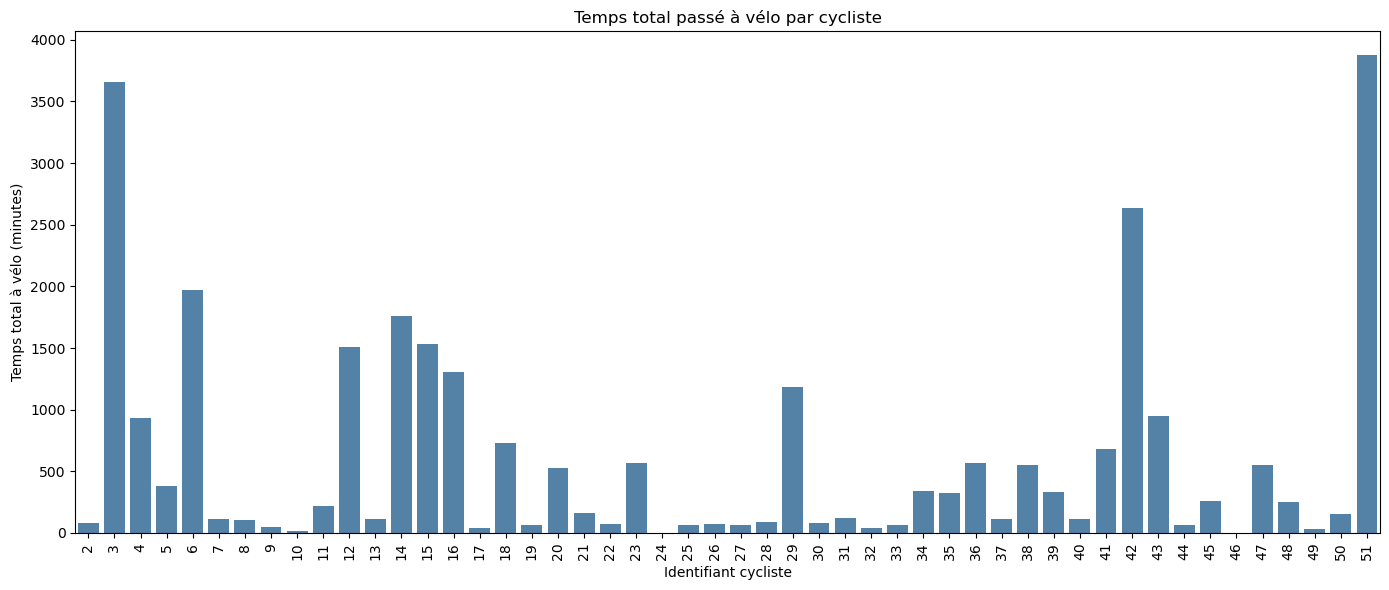

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.barplot(
    data=pdf_temps_total,
    x="id",
    y="temps_total_minutes",
    color="steelblue",
)
plt.xlabel("Identifiant cycliste")
plt.ylabel("Temps total à vélo (minutes)")
plt.title("Temps total passé à vélo par cycliste")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

2) Réalisez un graphique en barre qui affiche le temps de chaque trajet d'un cycliste. Faites en sorte qu'on puisse choisir un id et afficher les trajets de cet id.

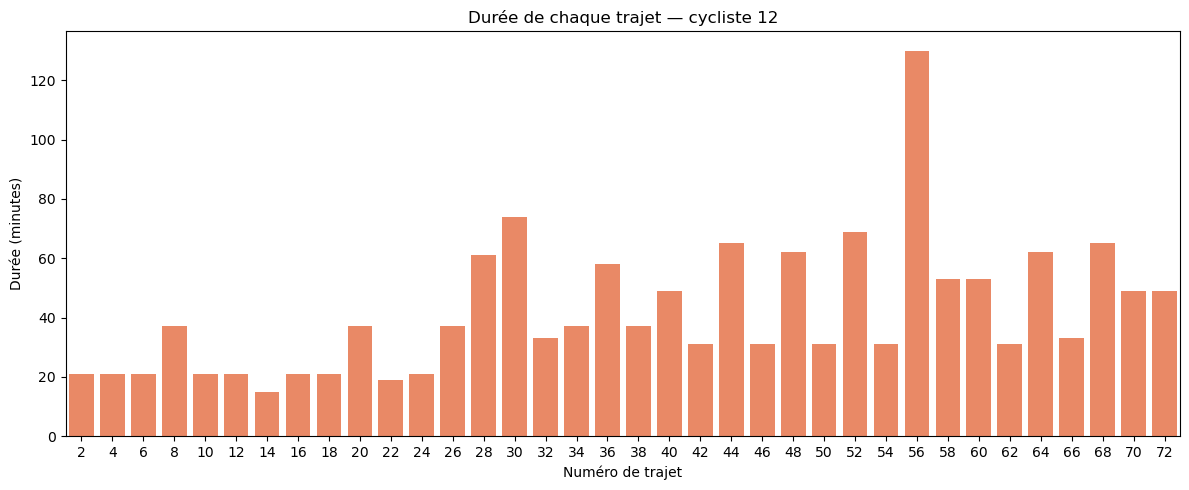

In [98]:
cycliste_id = 12  # modifier cet id pour afficher un autre cycliste

pdf_un_cycliste = pdf_trajets[pdf_trajets["id"] == cycliste_id].copy()
pdf_un_cycliste["label_trajet"] = pdf_un_cycliste["numero_de_trajet"].astype(str)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=pdf_un_cycliste,
    x="label_trajet",
    y="duree_trajet_minutes",
    color="coral",
)
plt.xlabel("Numéro de trajet")
plt.ylabel("Durée (minutes)")
plt.title(f"Durée de chaque trajet — cycliste {cycliste_id}")
plt.tight_layout()
plt.show()

## 6) Sauvegarde

Sauvegardez votre dataset trajets au format csv dans le dossier data.

In [99]:
(
    trajets.coalesce(1)
    .write.mode("overwrite")
    .option("header", True)
    .csv("./data/trajets")
)
print("Dataset sauvegardé dans ./data/trajets/")

Dataset sauvegardé dans ./data/trajets/
